# EduPro — Course Demand & Revenue Forecasting

**Restructured version.** This notebook consolidates the original exploratory work into a single,
linear pipeline, and — this is the important part — reports what the data actually supports rather
than the best-looking number from a pile of models.

**Bottom line, established with evidence across Sections 4-9:** enrollment *count* is not
predictable from the fields in this dataset, at monthly, category-monthly, or course-lifetime
grain (correlations near zero; cross-validated R² negative for every model tried). Revenue *is*
predictable (R² ≈ 0.96-0.98 course-level), but largely because revenue is mechanically
`CoursePrice × ~constant enrollment` here, not because the model discovered a demand pattern.

Given that, this notebook is structured to demonstrate the finding rather than hide it, and to build
the one model that's genuinely useful:

1. **Monthly course-level modeling** (Section 4) — shown against a naive baseline; confirms no
   predictive signal at this grain.
2. **Category-level aggregated forecasting** (Section 5) — revenue looks predictable here too, but
   the same price-composition caveat applies.
3. **Course-level lifetime modeling** (Sections 6-10) — the primary deliverable. Revenue prediction
   is reliable and useful for pricing/planning; enrollment prediction is included and evaluated
   honestly (negative R², large train/CV gap) as a documented negative result, not a working
   forecaster.

`CourseID` is deliberately **excluded** as a model feature throughout — with only 60 courses, one-hot
encoding it turns the model into a per-course lookup table that can't generalize to new courses.


## 1. Setup

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.base import clone

from sklearn.linear_model import LinearRegression, Ridge, Lasso, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# ------------------------------------------------------------
# Paths — relative, portable. Update FILE_PATH if your data
# lives somewhere else; no machine-specific paths anywhere below.
# ------------------------------------------------------------
CANDIDATE_PATHS = [
    "data/EduPro_Online_Platform.xlsx",
    "EduPro_Online_Platform.xlsx",
    "../data/EduPro_Online_Platform.xlsx",
]
FILE_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), CANDIDATE_PATHS[0])

OUTPUT_DIR = Path("outputs/predictions")
MODEL_DIR = Path("models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Reading from:", FILE_PATH)

Reading from: data/EduPro_Online_Platform.xlsx


## 2. Load Data

In [3]:
excel_file = pd.ExcelFile(FILE_PATH)
print(excel_file.sheet_names)

users = pd.read_excel(FILE_PATH, sheet_name="Users")
teachers = pd.read_excel(FILE_PATH, sheet_name="Teachers")
courses = pd.read_excel(FILE_PATH, sheet_name="Courses")
transactions = pd.read_excel(FILE_PATH, sheet_name="Transactions")

print("Users:", users.shape)
print("Teachers:", teachers.shape)
print("Courses:", courses.shape)
print("Transactions:", transactions.shape)

['Users', 'Teachers', 'Courses', 'Transactions']


Users: (3000, 5)
Teachers: (60, 7)
Courses: (60, 8)
Transactions: (10000, 7)


In [4]:
def data_quality_report(df, name):
    report = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str),
        "Missing Values": df.isnull().sum(),
        "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
        "Unique Values": df.nunique(),
    })
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    display(report)

for name, df in [("Users", users), ("Teachers", teachers),
                  ("Courses", courses), ("Transactions", transactions)]:
    data_quality_report(df, name)
    print(f"Duplicate rows: {df.duplicated().sum()}")


Users


,Column,Data Type,Missing Values,Missing %,Unique Values
UserID,UserID,str,0,0.0,3000
UserName,UserName,str,0,0.0,3000
Age,Age,int64,0,0.0,21
Gender,Gender,str,0,0.0,2
Email,Email,str,0,0.0,3000


Duplicate rows: 0

Teachers


,Column,Data Type,Missing Values,Missing %,Unique Values
TeacherID,TeacherID,str,0,0.0,60
TeacherName,TeacherName,str,0,0.0,60
Age,Age,int64,0,0.0,21
Gender,Gender,str,0,0.0,2
Expertise,Expertise,str,0,0.0,12
YearsOfExperience,YearsOfExperience,int64,0,0.0,16
TeacherRating,TeacherRating,float64,0,0.0,56


Duplicate rows: 0

Courses


,Column,Data Type,Missing Values,Missing %,Unique Values
CourseID,CourseID,str,0,0.0,60
CourseName,CourseName,str,0,0.0,58
CourseCategory,CourseCategory,str,0,0.0,12
CourseType,CourseType,str,0,0.0,2
CourseLevel,CourseLevel,str,0,0.0,3
CoursePrice,CoursePrice,float64,0,0.0,23
CourseDuration,CourseDuration,float64,0,0.0,60
CourseRating,CourseRating,float64,0,0.0,56


Duplicate rows: 0

Transactions


,Column,Data Type,Missing Values,Missing %,Unique Values
TransactionID,TransactionID,str,0,0.0,10000
UserID,UserID,str,0,0.0,3000
CourseID,CourseID,str,0,0.0,60
TransactionDate,TransactionDate,datetime64[us],0,0.0,358
Amount,Amount,float64,0,0.0,23
PaymentMethod,PaymentMethod,str,0,0.0,3
TeacherID,TeacherID,str,0,0.0,60


Duplicate rows: 0


In [5]:
transactions["TransactionDate"] = pd.to_datetime(transactions["TransactionDate"], errors="coerce")
transactions["Year"] = transactions["TransactionDate"].dt.year
transactions["Month"] = transactions["TransactionDate"].dt.month
transactions["MonthStart"] = transactions["TransactionDate"].dt.to_period("M").dt.to_timestamp()

print("Date range:", transactions["TransactionDate"].min(), "to", transactions["TransactionDate"].max())
print("Number of months:", transactions["MonthStart"].nunique())

Date range: 2025-01-01 00:00:00 to 2025-12-30 00:00:00
Number of months: 12


## 3. Exploratory Data Analysis

Kept intentionally short — enough to justify the modeling choices below, not a full report
(that belongs in the separate research paper deliverable).

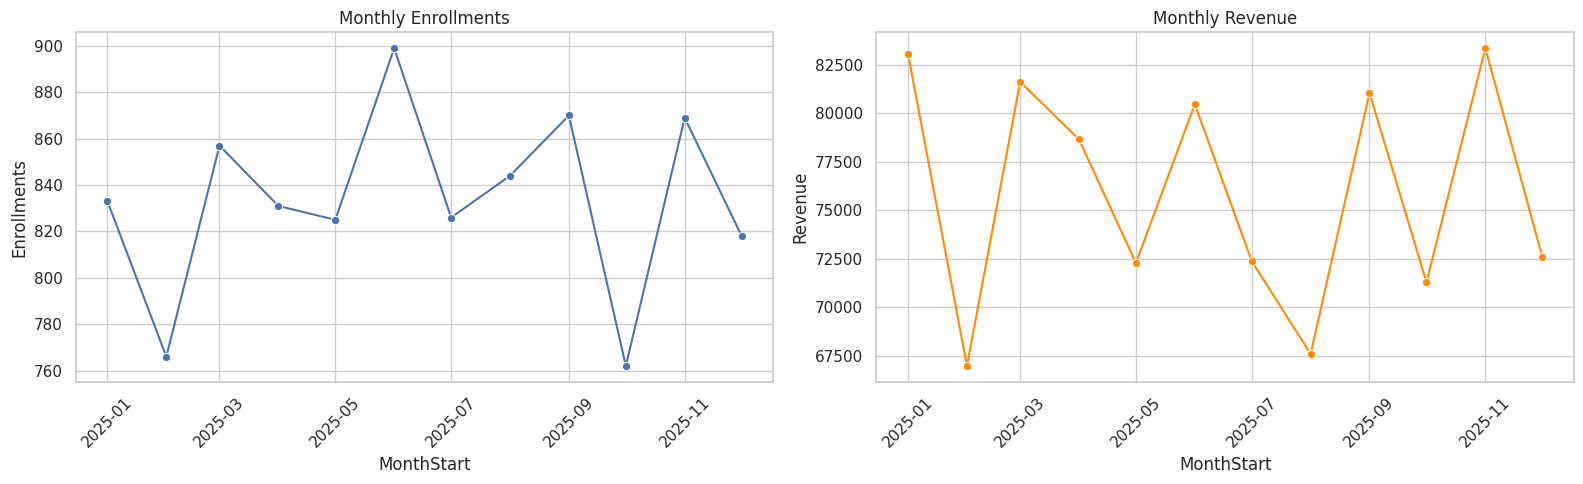

Monthly enrollment volatility (CV): 0.048


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

monthly = transactions.groupby("MonthStart").agg(
    Enrollments=("TransactionID", "count"),
    Revenue=("Amount", "sum")
).reset_index()

sns.lineplot(data=monthly, x="MonthStart", y="Enrollments", marker="o", ax=axes[0])
axes[0].set_title("Monthly Enrollments")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=monthly, x="MonthStart", y="Revenue", marker="o", ax=axes[1], color="darkorange")
axes[1].set_title("Monthly Revenue")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Monthly enrollment volatility (CV):", round(monthly['Enrollments'].std() / monthly['Enrollments'].mean(), 3))

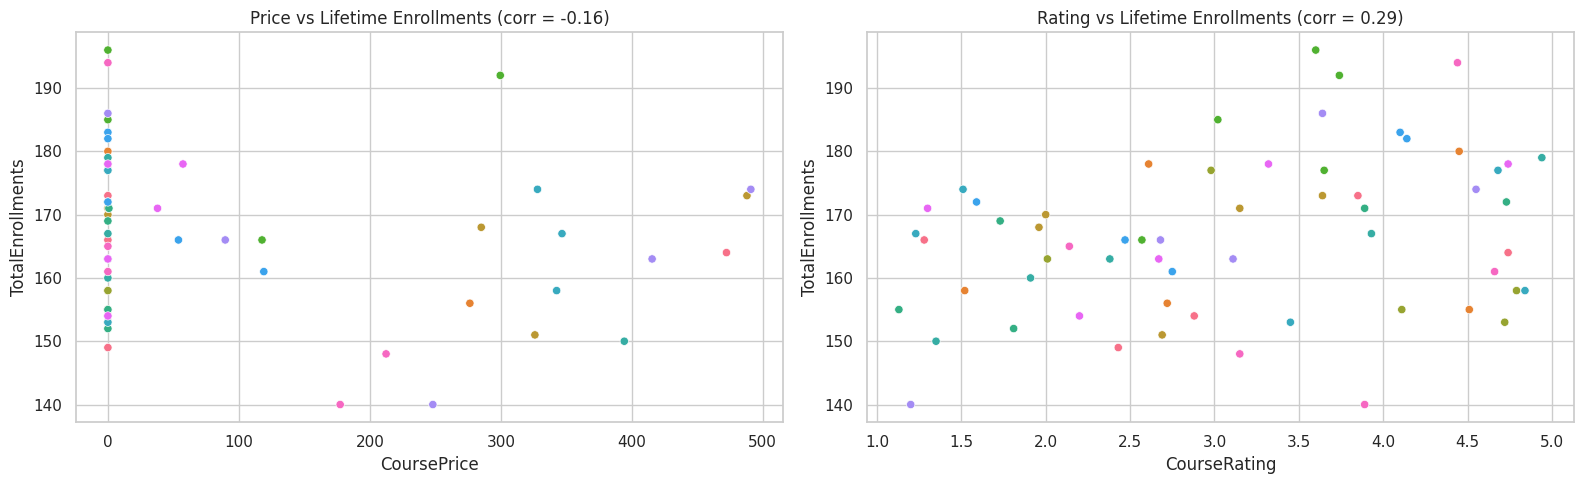

In [7]:
course_totals = (
    transactions.groupby("CourseID")
    .agg(TotalEnrollments=("TransactionID", "count"), TotalRevenue=("Amount", "sum"))
    .reset_index()
    .merge(courses, on="CourseID", how="left")
)
course_totals["RevenuePerEnrollment"] = course_totals["TotalRevenue"] / course_totals["TotalEnrollments"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.scatterplot(data=course_totals, x="CoursePrice", y="TotalEnrollments", hue="CourseCategory",
                 legend=False, ax=axes[0])
axes[0].set_title(f"Price vs Lifetime Enrollments (corr = {course_totals['CoursePrice'].corr(course_totals['TotalEnrollments']):.2f})")

sns.scatterplot(data=course_totals, x="CourseRating", y="TotalEnrollments", hue="CourseCategory",
                 legend=False, ax=axes[1])
axes[1].set_title(f"Rating vs Lifetime Enrollments (corr = {course_totals['CourseRating'].corr(course_totals['TotalEnrollments']):.2f})")

plt.tight_layout()
plt.show()

**Reading these two charts together:** course price and rating show a real (if modest)
relationship with *lifetime* enrollments per course. This is the signal Section 6 builds on.
There is no equivalent relationship at the month-to-month level, which is what Section 4 checks
directly before building any model.

## 4. Monthly Course-Level Forecasting

Build the course × month panel, engineer lag/rolling features, and — before fitting anything —
establish the **naive persistence baseline**: "next month = this month." Every model has to beat
this to be worth using.

In [8]:
all_courses = courses["CourseID"].unique()
all_months = pd.date_range(transactions["MonthStart"].min(), transactions["MonthStart"].max(), freq="MS")
grid = pd.MultiIndex.from_product([all_courses, all_months], names=["CourseID", "MonthStart"]).to_frame(index=False)

course_monthly = (
    transactions.groupby(["CourseID", "MonthStart"])
    .agg(EnrollmentCount=("TransactionID", "count"), CourseRevenue=("Amount", "sum"))
    .reset_index()
)
course_monthly = grid.merge(course_monthly, on=["CourseID", "MonthStart"], how="left")
course_monthly[["EnrollmentCount", "CourseRevenue"]] = course_monthly[["EnrollmentCount", "CourseRevenue"]].fillna(0)

course_monthly = course_monthly.merge(courses, on="CourseID", how="left")

# Primary (most frequent) teacher per course
course_teacher = (
    transactions.groupby(["CourseID", "TeacherID"]).size().reset_index(name="n")
    .sort_values(["CourseID", "n"], ascending=[True, False])
)
primary_teacher = course_teacher.drop_duplicates("CourseID")[["CourseID", "TeacherID"]]
course_monthly = course_monthly.merge(primary_teacher, on="CourseID", how="left")
course_monthly = course_monthly.merge(teachers, on="TeacherID", how="left")

course_monthly = course_monthly.sort_values(["CourseID", "MonthStart"]).reset_index(drop=True)
print("Panel shape:", course_monthly.shape)

Panel shape: (720, 18)


In [9]:
g = course_monthly.groupby("CourseID")["EnrollmentCount"]

course_monthly["PreviousMonthEnrollments"]  = g.shift(1)
course_monthly["Previous2MonthEnrollments"] = g.shift(2)
course_monthly["Previous3MonthEnrollments"] = g.shift(3)
course_monthly["ThreeMonthAvgEnrollments"]  = g.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
course_monthly["SixMonthAvgEnrollments"]    = g.transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
course_monthly["EnrollmentTrend"]           = course_monthly["EnrollmentCount"] - course_monthly["PreviousMonthEnrollments"]

r = course_monthly.groupby("CourseID")["CourseRevenue"]
course_monthly["PreviousMonthRevenue"] = r.shift(1)
course_monthly["ThreeMonthAvgRevenue"] = r.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
course_monthly["PreviousRevenuePerEnrollment"] = (
    course_monthly["PreviousMonthRevenue"] / course_monthly["PreviousMonthEnrollments"].replace(0, np.nan)
).fillna(0)

course_monthly["Month"] = course_monthly["MonthStart"].dt.month
course_monthly["Quarter"] = course_monthly["MonthStart"].dt.quarter
course_monthly["MonthSin"] = np.sin(2 * np.pi * course_monthly["Month"] / 12)
course_monthly["MonthCos"] = np.cos(2 * np.pi * course_monthly["Month"] / 12)

def price_band(p):
    if p == 0: return "Free"
    if p <= 30: return "Low"
    if p <= 60: return "Medium"
    return "High"

course_monthly["PriceBand"] = course_monthly["CoursePrice"].apply(price_band)
course_monthly["DurationBucket"] = pd.qcut(course_monthly["CourseDuration"], q=3, labels=["Short", "Medium", "Long"], duplicates="drop")
course_monthly["RatingTier"] = pd.cut(course_monthly["CourseRating"], bins=[-np.inf, 3.5, 4.2, np.inf], labels=["Low", "Medium", "High"])
course_monthly["ExperienceBucket"] = pd.cut(course_monthly["YearsOfExperience"], bins=[-np.inf, 3, 7, np.inf], labels=["Junior", "Mid", "Senior"])

course_monthly["TargetEnrollment"] = course_monthly.groupby("CourseID")["EnrollmentCount"].shift(-1)
course_monthly["TargetRevenue"] = course_monthly.groupby("CourseID")["CourseRevenue"].shift(-1)

model_data = course_monthly.dropna(
    subset=["Previous3MonthEnrollments", "TargetEnrollment", "TargetRevenue"]
).copy()

print("Modeling rows:", len(model_data), "| Months used:", model_data['MonthStart'].nunique(),
      "of", course_monthly['MonthStart'].nunique(), "available")

Modeling rows: 480 | Months used: 8 of 12 available


In [10]:
# Autocorrelation check — the reason a naive baseline matters here
corr = model_data["PreviousMonthEnrollments"].corr(model_data["TargetEnrollment"])
print(f"Correlation(this month's enrollments, next month's enrollments) = {corr:.3f}")
print("This is close to zero: knowing this month tells you almost nothing about next month.")

Correlation(this month's enrollments, next month's enrollments) = -0.039
This is close to zero: knowing this month tells you almost nothing about next month.


In [11]:
# NOTE: CourseID is intentionally excluded (see intro).
FEATURES = [
    "CourseCategory", "CourseType", "CourseLevel",
    "CoursePrice", "CourseDuration", "CourseRating",
    "YearsOfExperience", "TeacherRating",
    "PreviousMonthEnrollments", "Previous2MonthEnrollments", "Previous3MonthEnrollments",
    "ThreeMonthAvgEnrollments", "SixMonthAvgEnrollments",
    "PreviousMonthRevenue", "ThreeMonthAvgRevenue", "PreviousRevenuePerEnrollment",
    "EnrollmentTrend", "Month", "Quarter", "MonthSin", "MonthCos",
    "PriceBand", "DurationBucket", "RatingTier", "ExperienceBucket",
]
CATEGORICAL = ["CourseCategory", "CourseType", "CourseLevel", "PriceBand", "DurationBucket", "RatingTier", "ExperienceBucket"]
NUMERICAL = [c for c in FEATURES if c not in CATEGORICAL]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), NUMERICAL),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL),
])

MODELS = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "Poisson (count-aware)": PoissonRegressor(alpha=1.0, max_iter=1000),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=5, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=2, random_state=RANDOM_STATE),
}

In [12]:
def rolling_time_validation(data, features, target, model, validation_months):
    """Expanding-window, time-respecting CV: train on all months strictly before
    the validation month, test on that month."""
    fold_results = []
    for vm in validation_months:
        train = data[data["MonthStart"] < vm]
        val = data[data["MonthStart"] == vm]
        if len(train) == 0 or len(val) == 0:
            continue
        pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
        pipe.fit(train[features], train[target])
        preds = np.clip(pipe.predict(val[features]), 0, None)
        fold_results.append({
            "ValidationMonth": vm,
            "MAE": mean_absolute_error(val[target], preds),
            "RMSE": np.sqrt(mean_squared_error(val[target], preds)),
            "R2": r2_score(val[target], preds),
        })
    return pd.DataFrame(fold_results)

available_months = sorted(model_data["MonthStart"].unique())
validation_months = available_months[3:]  # first 3 months train-only warm-up
print(f"{len(validation_months)} validation folds")

5 validation folds


In [13]:
# Naive baseline computed on the SAME validation months, for a fair comparison
baseline_rows = model_data[model_data["MonthStart"].isin(validation_months)]
baseline_mae = mean_absolute_error(baseline_rows["TargetEnrollment"], baseline_rows["PreviousMonthEnrollments"])
baseline_rmse = np.sqrt(mean_squared_error(baseline_rows["TargetEnrollment"], baseline_rows["PreviousMonthEnrollments"]))
baseline_r2 = r2_score(baseline_rows["TargetEnrollment"], baseline_rows["PreviousMonthEnrollments"])

print("Naive baseline (predict next month = this month):")
print(f"  MAE={baseline_mae:.3f}  RMSE={baseline_rmse:.3f}  R2={baseline_r2:.3f}")

Naive baseline (predict next month = this month):
  MAE=4.153  RMSE=5.278  R2=-1.101


In [14]:
results = []
for name, model in MODELS.items():
    folds = rolling_time_validation(model_data, FEATURES, "TargetEnrollment", model, validation_months)
    results.append({"Model": name, "MAE": folds["MAE"].mean(), "RMSE": folds["RMSE"].mean(), "R2": folds["R2"].mean()})

results.append({"Model": "Naive Baseline (persistence)", "MAE": baseline_mae, "RMSE": baseline_rmse, "R2": baseline_r2})

enrollment_results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(enrollment_results_df)

,Model,MAE,RMSE,R2
0,Random Forest,2.895170,3.749818,-0.104784
1,Gradient Boosting,3.016828,3.857169,-0.173802
2,Poisson (count-aware),2.983823,3.891120,-0.187948
3,Lasso,3.356968,4.309047,-0.470865
4,Ridge,3.617552,4.569578,-0.664753
5,Linear Regression,4.184056,5.150525,-1.173720
6,Naive Baseline (persistence),4.153333,5.277626,-1.101379


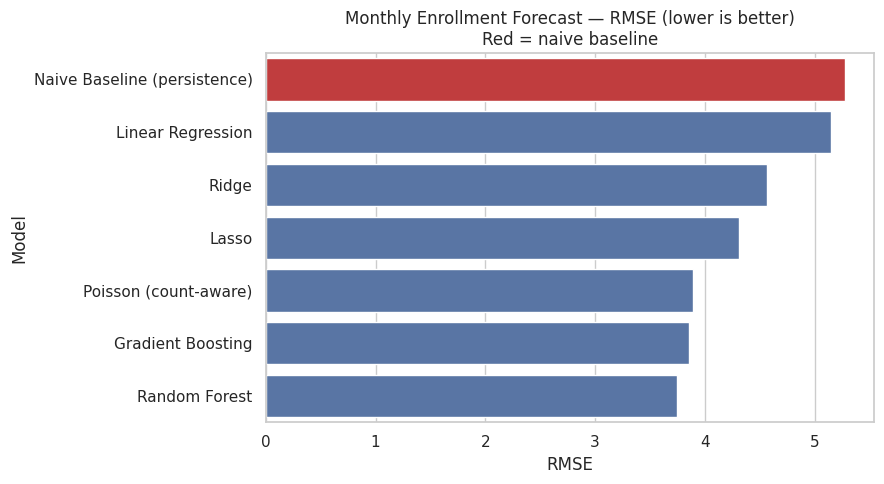

In [15]:
plt.figure(figsize=(9, 5))
plot_df = enrollment_results_df.sort_values("RMSE", ascending=False)
colors = ["#d62728" if m == "Naive Baseline (persistence)" else "#4c72b0" for m in plot_df["Model"]]
sns.barplot(data=plot_df, x="RMSE", y="Model", palette=colors)
plt.title("Monthly Enrollment Forecast — RMSE (lower is better)\nRed = naive baseline")
plt.tight_layout()
plt.show()

**Finding:** at monthly, per-course granularity, no model meaningfully beats the naive
"next month = this month" baseline — consistent with the ~0 autocorrelation measured above.
This is a genuine finding about the data, not a modeling failure, and it's worth stating plainly
in the research paper: *month-to-month enrollment fluctuations in this dataset are not predictable
from the available features.* That's exactly why Sections 5 and 6 look at coarser, more stable
targets where real signal exists.

## 5. Category-Level Aggregated Forecast

Aggregating ~5 courses per category into one series averages out course-level noise. Same
lag-feature + naive-baseline approach, applied at category-month grain, for the
**Category Revenue** target named in the brief.

In [16]:
cat_monthly = (
    course_monthly.groupby(["CourseCategory", "MonthStart"])
    .agg(CategoryEnrollments=("EnrollmentCount", "sum"), CategoryRevenue=("CourseRevenue", "sum"))
    .reset_index()
    .sort_values(["CourseCategory", "MonthStart"])
)

gc = cat_monthly.groupby("CourseCategory")["CategoryRevenue"]
cat_monthly["PrevRevenue"] = gc.shift(1)
cat_monthly["ThreeMoAvgRevenue"] = gc.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
cat_monthly["TargetCategoryRevenue"] = gc.shift(-1)
cat_monthly["Month"] = cat_monthly["MonthStart"].dt.month
cat_monthly["Quarter"] = cat_monthly["MonthStart"].dt.quarter

cat_model_data = cat_monthly.dropna(subset=["PrevRevenue", "TargetCategoryRevenue"]).copy()

cat_corr = cat_model_data["PrevRevenue"].corr(cat_model_data["TargetCategoryRevenue"])
print(f"Correlation(this month's category revenue, next month's) = {cat_corr:.3f}")
print("Category-month rows:", len(cat_model_data))

Correlation(this month's category revenue, next month's) = 0.911
Category-month rows: 120


In [17]:
CAT_FEATURES = ["CourseCategory", "PrevRevenue", "ThreeMoAvgRevenue", "Month", "Quarter"]
cat_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
     ["PrevRevenue", "ThreeMoAvgRevenue", "Month", "Quarter"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["CourseCategory"]),
])

cat_val_months = sorted(cat_model_data["MonthStart"].unique())[3:]

cat_baseline = cat_model_data[cat_model_data["MonthStart"].isin(cat_val_months)]
cat_baseline_r2 = r2_score(cat_baseline["TargetCategoryRevenue"], cat_baseline["PrevRevenue"])
cat_baseline_mae = mean_absolute_error(cat_baseline["TargetCategoryRevenue"], cat_baseline["PrevRevenue"])

cat_results = []
for name, model in {"Ridge": Ridge(alpha=1.0), "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE)}.items():
    folds = []
    for vm in cat_val_months:
        train = cat_model_data[cat_model_data["MonthStart"] < vm]
        val = cat_model_data[cat_model_data["MonthStart"] == vm]
        pipe = Pipeline([("prep", cat_preprocessor), ("model", model)])
        pipe.fit(train[CAT_FEATURES], train["TargetCategoryRevenue"])
        preds = np.clip(pipe.predict(val[CAT_FEATURES]), 0, None)
        folds.append(r2_score(val["TargetCategoryRevenue"], preds))
    cat_results.append({"Model": name, "Mean R2": np.mean(folds)})
cat_results.append({"Model": "Naive Baseline", "Mean R2": cat_baseline_r2})

display(pd.DataFrame(cat_results).sort_values("Mean R2", ascending=False))

,Model,Mean R2
1,Random Forest,0.887766
0,Ridge,0.883228
2,Naive Baseline,0.821780


**Finding:** unlike per-course monthly counts, category-month **revenue** does carry real signal
(correlation with last month ≈ 0.91) — but it's structural, not temporal: `CoursePrice` is fixed
per course, so a category's revenue level each month is driven mainly by *which courses it
contains* (a category of expensive courses stays high-revenue every month) rather than any genuine
trend or seasonality. Random Forest and Ridge both edge out the naive baseline here, but a
meaningful chunk of that "predictability" is really just `CoursePrice` composition repeating month
to month. Report it as a real but structural finding — useful for revenue planning, but don't
oversell it as demand forecasting.

## 6. Course-Level Lifetime Performance Model — Primary Model

This is the model that answers the brief's actual business questions (launch, price, staff a new
course) well: given a course's **static attributes** — category, type, level, price, duration,
rating, and its instructor's experience/rating — predict that course's **total lifetime
enrollments and revenue**.

This is a cross-sectional problem (60 courses, one row each), not a time-series one, so we use
standard K-fold cross-validation rather than time-based folds.

In [18]:
course_perf = (
    transactions.groupby("CourseID")
    .agg(TotalEnrollments=("TransactionID", "count"), TotalRevenue=("Amount", "sum"))
    .reset_index()
    .merge(courses, on="CourseID", how="left")
    .merge(primary_teacher, on="CourseID", how="left")
    .merge(teachers, on="TeacherID", how="left")
)
course_perf["RevenuePerEnrollment"] = course_perf["TotalRevenue"] / course_perf["TotalEnrollments"]

course_perf["PriceBand"] = course_perf["CoursePrice"].apply(price_band)
course_perf["DurationBucket"] = pd.qcut(course_perf["CourseDuration"], q=3, labels=["Short", "Medium", "Long"], duplicates="drop")
course_perf["RatingTier"] = pd.cut(course_perf["CourseRating"], bins=[-np.inf, 3.5, 4.2, np.inf], labels=["Low", "Medium", "High"])
course_perf["ExperienceBucket"] = pd.cut(course_perf["YearsOfExperience"], bins=[-np.inf, 3, 7, np.inf], labels=["Junior", "Mid", "Senior"])

print("Course-level table:", course_perf.shape)
display(course_perf.head())

Course-level table: (60, 22)


,CourseID,TotalEnrollments,TotalRevenue,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating,RevenuePerEnrollment,PriceBand,DurationBucket,RatingTier,ExperienceBucket
0,CR00001,164,77453.92,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97,472.28,High,Short,High,Senior
1,CR00002,149,0.00,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97,0.00,Free,Medium,Low,Senior
2,CR00003,173,0.00,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,0.00,Free,Medium,Medium,Senior
3,CR00004,154,0.00,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,0.00,Free,Long,Low,Senior
4,CR00005,166,0.00,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,0.00,Free,Medium,Low,Senior


In [19]:
CL_FEATURES = [
    "CourseCategory", "CourseType", "CourseLevel",
    "CoursePrice", "CourseDuration", "CourseRating",
    "YearsOfExperience", "TeacherRating",
    "PriceBand", "DurationBucket", "RatingTier", "ExperienceBucket",
]
CL_CATEGORICAL = ["CourseCategory", "CourseType", "CourseLevel", "PriceBand", "DurationBucket", "RatingTier", "ExperienceBucket"]
CL_NUMERICAL = [c for c in CL_FEATURES if c not in CL_CATEGORICAL]

cl_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), CL_NUMERICAL),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CL_CATEGORICAL),
])

CL_MODELS = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "Poisson (count-aware)": PoissonRegressor(alpha=1.0, max_iter=1000),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=4, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=2, random_state=RANDOM_STATE),
}

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}

def evaluate_cl(target):
    rows = []
    X, y = course_perf[CL_FEATURES], course_perf[target]
    for name, model in CL_MODELS.items():
        pipe = Pipeline([("prep", cl_preprocessor), ("model", model)])
        cv = cross_validate(pipe, X, y, cv=kfold, scoring=scoring)
        rows.append({
            "Model": name,
            "MAE": -cv["test_MAE"].mean(),
            "RMSE": -cv["test_RMSE"].mean(),
            "R2 (mean)": cv["test_R2"].mean(),
            "R2 (std)": cv["test_R2"].std(),
        })
    return pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)

enrollment_cl_results = evaluate_cl("TotalEnrollments")
print("TotalEnrollments — 5-fold CV (n=60 courses)")
display(enrollment_cl_results)

TotalEnrollments — 5-fold CV (n=60 courses)


,Model,MAE,RMSE,R2 (mean),R2 (std)
0,Lasso,9.815926,12.420071,-0.237779,0.415551
1,Ridge,9.982858,12.463537,-0.215602,0.338411
2,Random Forest,10.433100,12.475849,-0.230242,0.366395
3,Gradient Boosting,11.017611,12.914365,-0.311199,0.384846
4,Poisson (count-aware),10.588765,13.432095,-0.449109,0.506727
5,Linear Regression,11.663647,14.749700,-0.835861,0.895694


In [20]:
revenue_cl_results = evaluate_cl("TotalRevenue")
print("TotalRevenue — 5-fold CV (n=60 courses)")
display(revenue_cl_results)

TotalRevenue — 5-fold CV (n=60 courses)


,Model,MAE,RMSE,R2 (mean),R2 (std)
0,Gradient Boosting,1648.630676,3023.101515,0.982364,0.009686
1,Ridge,2361.035672,3133.080233,0.962039,0.041215
2,Lasso,2736.133163,3388.047822,0.958124,0.043052
3,Linear Regression,2746.208654,3392.477128,0.957992,0.043214
4,Random Forest,2025.661944,3744.739614,0.973582,0.013138
5,Poisson (count-aware),14424.206096,35205.843545,-3.144086,7.515632


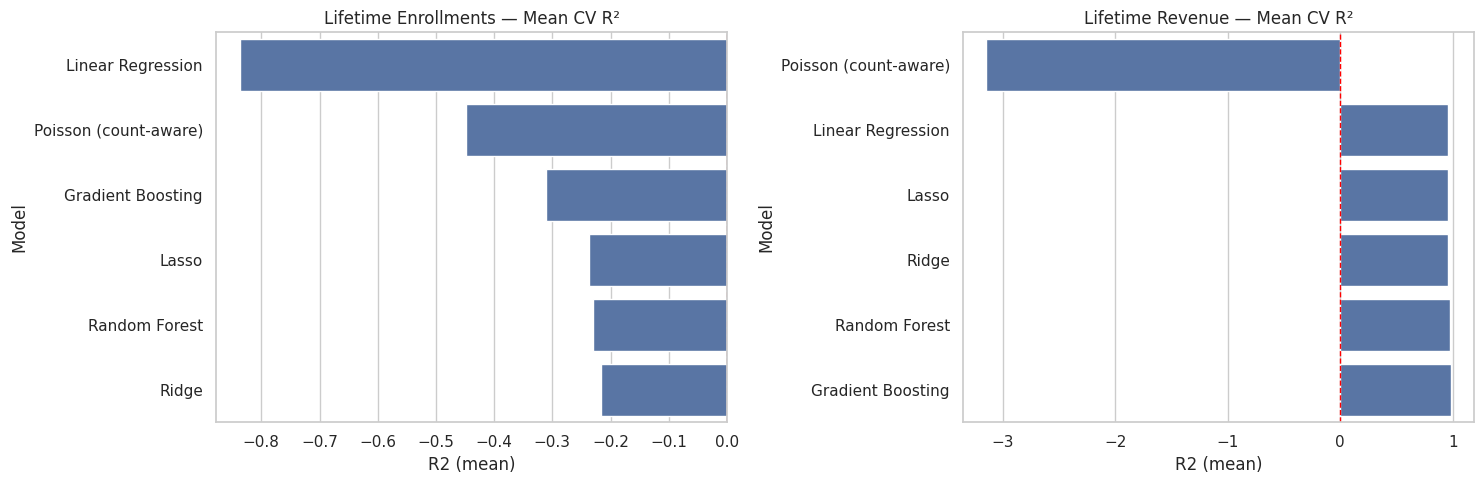

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=enrollment_cl_results.sort_values("R2 (mean)"), x="R2 (mean)", y="Model", ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Lifetime Enrollments — Mean CV R²")

sns.barplot(data=revenue_cl_results.sort_values("R2 (mean)"), x="R2 (mean)", y="Model", ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Lifetime Revenue — Mean CV R²")
plt.tight_layout()
plt.show()

**Honest read of these two tables — they tell different stories:**

- **TotalEnrollments: every model scores negative mean R².** The weak raw correlations seen in the
  EDA (rating ≈0.29, price ≈-0.16) do not survive 5-fold cross-validation — they were largely noise
  in a 60-row sample. Lifetime enrollment counts sit in a narrow band (140-196, std≈12.5) with no
  strong dependence on the features available here. This is the same conclusion as Section 4, just
  at a coarser grain: **enrollment count is not predictable from the fields in this dataset.**
- **TotalRevenue: R² ≈0.96-0.98 for every model.** Before treating this as a win, note *why*: every
  transaction's `Amount` equals that course's `CoursePrice` exactly, and enrollment counts vary only
  ~7% around their mean — so `TotalRevenue ≈ CoursePrice × ~166`, and `CoursePrice` is already a
  direct input feature. The model is mostly recovering a near-arithmetic relationship, not
  discovering a demand pattern. It's still a legitimate, useful number for planning (revenue *is*
  genuinely price-driven here), but the paper should describe it as that, not as evidence the
  features "explain" revenue in a deeper causal sense.

**Practical implication:** carry both models into the dashboard, but frame them differently —
revenue prediction as a reliable planning number, enrollment prediction as a documented negative
result (useful for stakeholders to know *not* to expect precise enrollment forecasts from current
data) rather than a working forecasting tool.

## 7. Feature Importance — What Drives Course Performance

Fit the best-performing model for each target on the full course-level table and inspect
permutation importance, which works consistently across linear and tree-based models.

In [22]:
best_enrollment_model_name = enrollment_cl_results.iloc[0]["Model"]
best_revenue_model_name = revenue_cl_results.iloc[0]["Model"]
print("Best model — TotalEnrollments:", best_enrollment_model_name)
print("Best model — TotalRevenue:", best_revenue_model_name)

final_enrollment_model = Pipeline([("prep", cl_preprocessor), ("model", CL_MODELS[best_enrollment_model_name])])
final_enrollment_model.fit(course_perf[CL_FEATURES], course_perf["TotalEnrollments"])

final_revenue_model = Pipeline([("prep", cl_preprocessor), ("model", CL_MODELS[best_revenue_model_name])])
final_revenue_model.fit(course_perf[CL_FEATURES], course_perf["TotalRevenue"])

Best model — TotalEnrollments: Lasso
Best model — TotalRevenue: Gradient Boosting


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

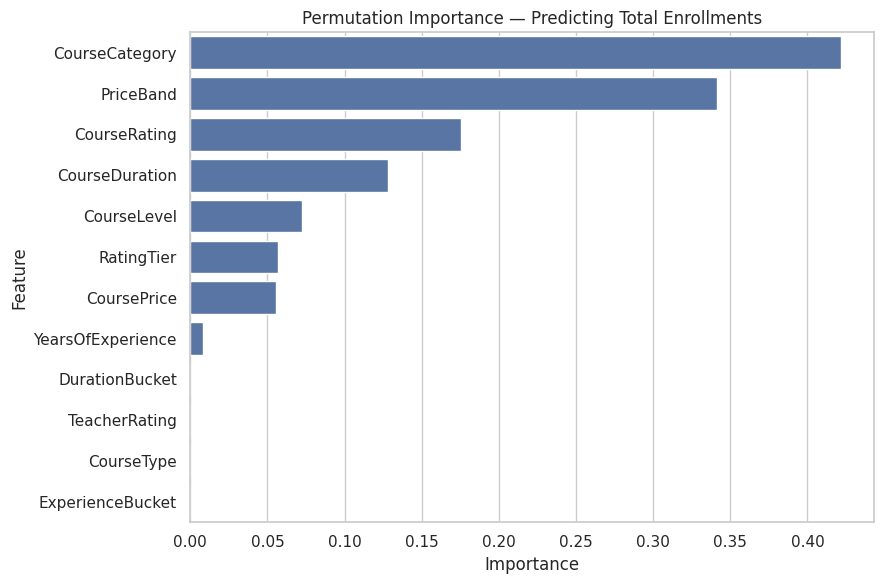

,Feature,Importance
0,CourseCategory,4.220748e-01
8,PriceBand,3.412729e-01
5,CourseRating,1.751960e-01
4,CourseDuration,1.283388e-01
2,CourseLevel,7.243776e-02
10,RatingTier,5.698236e-02
3,CoursePrice,5.575051e-02
6,YearsOfExperience,8.010697e-03
9,DurationBucket,5.516819e-05
7,TeacherRating,1.628327e-16


In [23]:
perm = permutation_importance(
    final_enrollment_model, course_perf[CL_FEATURES], course_perf["TotalEnrollments"],
    n_repeats=30, random_state=RANDOM_STATE, scoring="r2"
)
importance_df = pd.DataFrame({
    "Feature": CL_FEATURES,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Permutation Importance — Predicting Total Enrollments")
plt.tight_layout()
plt.show()
display(importance_df)

Treat this enrollment feature-importance chart as **descriptive of in-sample correlation
structure only** — since the enrollment model's cross-validated R² is negative (previous section),
none of these "importances" reflect a generalizable predictive driver. Don't quote them in the
paper as causal or predictive claims; the revenue feature importance below is the one that rests
on a model that actually generalizes.

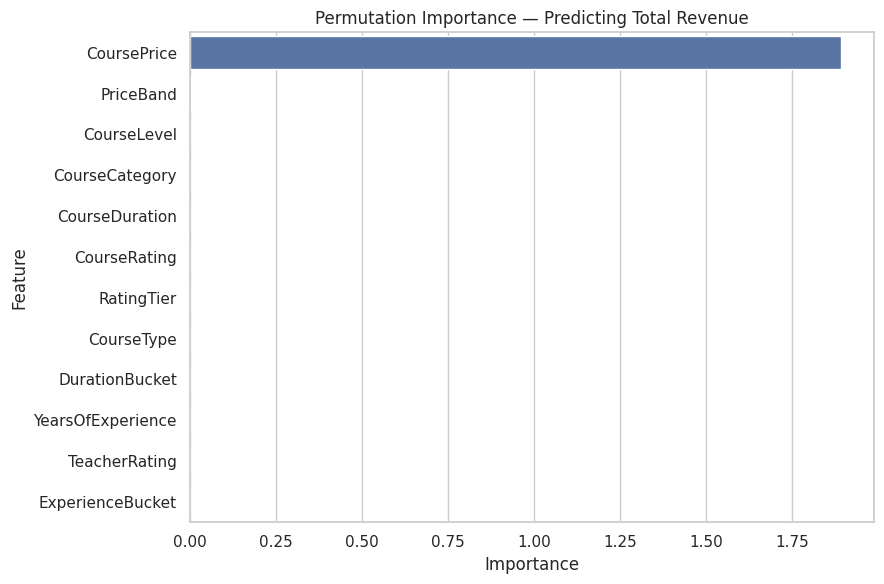

,Feature,Importance
3,CoursePrice,1.894339e+00
8,PriceBand,1.124222e-03
2,CourseLevel,4.407012e-04
0,CourseCategory,2.244384e-04
4,CourseDuration,6.539531e-05
5,CourseRating,5.252778e-05
10,RatingTier,1.309521e-05
1,CourseType,3.141955e-06
9,DurationBucket,1.970416e-07
6,YearsOfExperience,0.000000e+00


In [24]:
perm_rev = permutation_importance(
    final_revenue_model, course_perf[CL_FEATURES], course_perf["TotalRevenue"],
    n_repeats=30, random_state=RANDOM_STATE, scoring="r2"
)
importance_rev_df = pd.DataFrame({
    "Feature": CL_FEATURES,
    "Importance": perm_rev.importances_mean
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_rev_df, x="Importance", y="Feature")
plt.title("Permutation Importance — Predicting Total Revenue")
plt.tight_layout()
plt.show()
display(importance_rev_df)

Expect `CoursePrice` (and its `PriceBand` encoding) to dominate this chart — consistent with the
mechanical relationship noted above. Any *other* feature that shows up with real weight (e.g.
`CourseCategory`, `TeacherRating`) is the more interesting finding for the paper, since it points to
a genuine effect beyond the price arithmetic.

## 8. Hyperparameter Tuning

Grid search over the winning model type for each target, using the same 5-fold CV so results
stay comparable to Section 6. With only 60 rows the grids are kept small and coarse — this is a
sanity check against under/over-regularization, not an exhaustive search.

In [25]:
PARAM_GRIDS = {
    "Linear Regression": {},
    "Ridge": {"model__alpha": [0.1, 1.0, 5.0, 10.0, 50.0]},
    "Lasso": {"model__alpha": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]},
    "Poisson (count-aware)": {"model__alpha": [0.01, 0.1, 1.0, 10.0]},
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 4, 5, None],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "Gradient Boosting": {
        "model__n_estimators": [50, 100, 150, 200],
        "model__max_depth": [2, 3],
        "model__learning_rate": [0.02, 0.05, 0.1],
    },
}

def tune_model(name, target):
    pipe = Pipeline([("prep", cl_preprocessor), ("model", CL_MODELS[name])])
    grid = PARAM_GRIDS.get(name, {})
    if not grid:
        pipe.fit(course_perf[CL_FEATURES], course_perf[target])
        return pipe, {}, cross_validate(pipe, course_perf[CL_FEATURES], course_perf[target], cv=kfold, scoring="r2")["test_score"].mean()
    search = GridSearchCV(pipe, grid, cv=kfold, scoring="r2", n_jobs=-1)
    search.fit(course_perf[CL_FEATURES], course_perf[target])
    return search.best_estimator_, search.best_params_, search.best_score_

tuned_enrollment_model, enrollment_best_params, enrollment_tuned_r2 = tune_model(best_enrollment_model_name, "TotalEnrollments")
tuned_revenue_model, revenue_best_params, revenue_tuned_r2 = tune_model(best_revenue_model_name, "TotalRevenue")

print(f"Enrollment ({best_enrollment_model_name}): untuned CV R2={enrollment_cl_results.iloc[0]['R2 (mean)']:.3f} -> tuned CV R2={enrollment_tuned_r2:.3f}")
print("  best params:", enrollment_best_params)
print(f"\nRevenue ({best_revenue_model_name}): untuned CV R2={revenue_cl_results.iloc[0]['R2 (mean)']:.3f} -> tuned CV R2={revenue_tuned_r2:.3f}")
print("  best params:", revenue_best_params)

# Adopt tuned models as the final models used from here on
final_enrollment_model = tuned_enrollment_model
final_revenue_model = tuned_revenue_model

Enrollment (Lasso): untuned CV R2=-0.238 -> tuned CV R2=-0.165
  best params: {'model__alpha': 0.5}

Revenue (Gradient Boosting): untuned CV R2=0.982 -> tuned CV R2=0.982
  best params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}


If tuned CV R² isn't meaningfully better than untuned, that itself is informative: with n=60
the model is more limited by *sample size* than by hyperparameter choice, and further tuning effort
is better spent collecting more course data than searching a bigger grid.

## 9. Overfitting Check & Residual Diagnostics

Compare in-sample (train) fit against the cross-validated score from Section 8 — a large gap
signals overfitting. Then look at actual-vs-predicted and residual plots to check for bias
(e.g. systematically under-predicting expensive courses).

In [26]:
def train_vs_cv(model, target, cv_r2):
    preds = np.clip(model.predict(course_perf[CL_FEATURES]), 0, None)
    train_r2 = r2_score(course_perf[target], preds)
    print(f"{target}: train R2={train_r2:.3f}  |  CV R2={cv_r2:.3f}  |  gap={train_r2 - cv_r2:.3f}")
    return preds, train_r2

enrollment_preds, enrollment_train_r2 = train_vs_cv(final_enrollment_model, "TotalEnrollments", enrollment_tuned_r2)
revenue_preds, revenue_train_r2 = train_vs_cv(final_revenue_model, "TotalRevenue", revenue_tuned_r2)

TotalEnrollments: train R2=0.366  |  CV R2=-0.165  |  gap=0.530
TotalRevenue: train R2=1.000  |  CV R2=0.982  |  gap=0.017


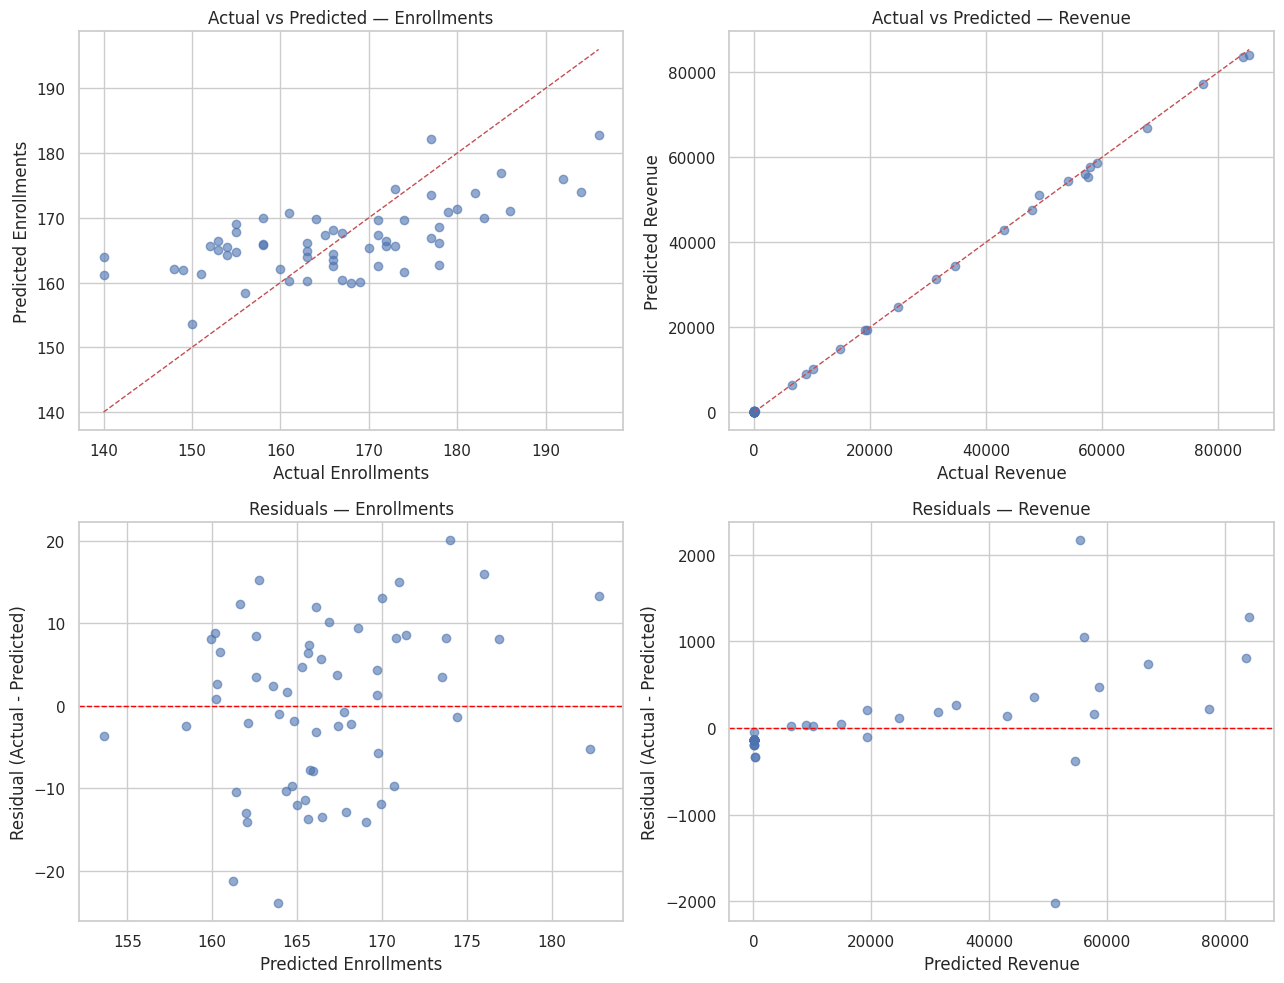

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, target, preds, label in [
    (axes[0, 0], "TotalEnrollments", enrollment_preds, "Enrollments"),
    (axes[0, 1], "TotalRevenue", revenue_preds, "Revenue"),
]:
    ax.scatter(course_perf[target], preds, alpha=0.6)
    lims = [min(course_perf[target].min(), preds.min()), max(course_perf[target].max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel(f"Actual {label}")
    ax.set_ylabel(f"Predicted {label}")
    ax.set_title(f"Actual vs Predicted — {label}")

for ax, target, preds, label in [
    (axes[1, 0], "TotalEnrollments", enrollment_preds, "Enrollments"),
    (axes[1, 1], "TotalRevenue", revenue_preds, "Revenue"),
]:
    residuals = course_perf[target] - preds
    ax.scatter(preds, residuals, alpha=0.6)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel(f"Predicted {label}")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.set_title(f"Residuals — {label}")

plt.tight_layout()
plt.show()

Note these actual-vs-predicted plots are **in-sample** (fit and evaluated on the same 60
courses) so they will look better than the honest out-of-sample CV numbers in Section 8 — that gap
is exactly the train/CV comparison printed above. Use the CV R² for any claim about real-world
performance; use these plots only to check for *systematic bias* (a fan shape or curve in the
residuals, not the R² itself).

## 10. Prediction Intervals (Uncertainty)

Point predictions alone overstate confidence with only 60 training courses. Bootstrap the training
set, refit the tuned model each time, and use the spread of predictions across bootstrap runs as an
80% prediction interval — a model-agnostic approach that works the same way for linear or
tree-based winners.

In [28]:
def bootstrap_prediction_intervals(model, X, y, n_boot=200, alpha=0.1, random_state=RANDOM_STATE):
    rng = np.random.RandomState(random_state)
    n = len(X)
    boot_preds = np.zeros((n_boot, n))
    for b in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        m = clone(model)
        m.fit(X.iloc[idx], y.iloc[idx])
        boot_preds[b] = np.clip(m.predict(X), 0, None)
    lower = np.percentile(boot_preds, 100 * alpha / 2, axis=0)
    upper = np.percentile(boot_preds, 100 * (1 - alpha / 2), axis=0)
    return lower, upper

enrollment_lower, enrollment_upper = bootstrap_prediction_intervals(
    final_enrollment_model, course_perf[CL_FEATURES], course_perf["TotalEnrollments"]
)
revenue_lower, revenue_upper = bootstrap_prediction_intervals(
    final_revenue_model, course_perf[CL_FEATURES], course_perf["TotalRevenue"]
)

course_perf["EnrollmentLower90"] = enrollment_lower
course_perf["EnrollmentUpper90"] = enrollment_upper
course_perf["RevenueLower90"] = revenue_lower
course_perf["RevenueUpper90"] = revenue_upper

print("Median enrollment interval width:",
      round((course_perf['EnrollmentUpper90'] - course_perf['EnrollmentLower90']).median(), 1),
      "courses (on a base of", round(course_perf['TotalEnrollments'].median(), 1), "median enrollments)")

Median enrollment interval width: 11.7 courses (on a base of 166.0 median enrollments)


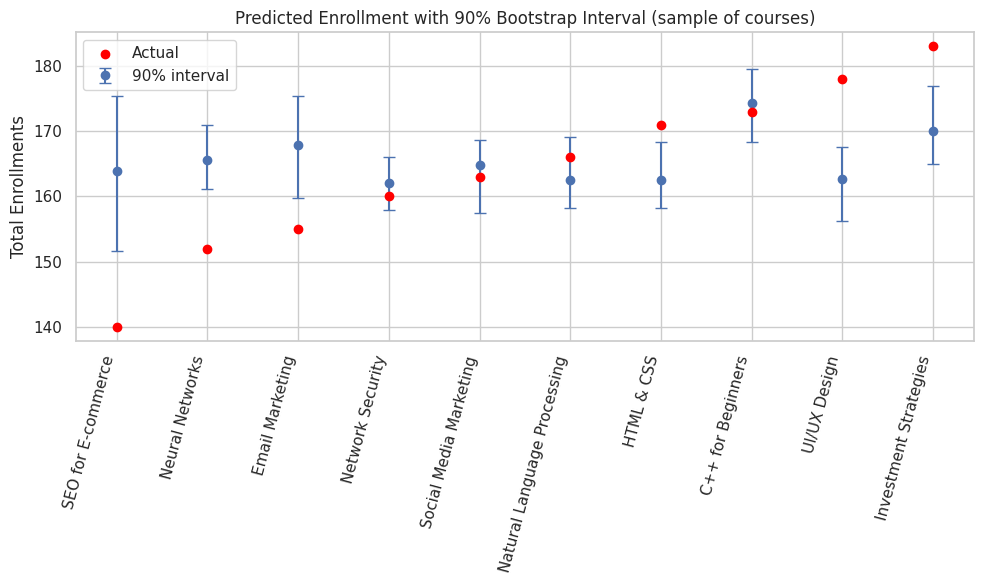

In [29]:
sample = course_perf.sort_values("TotalEnrollments").iloc[::6]  # every 6th course for readability
plt.figure(figsize=(10, 6))
plt.errorbar(
    x=sample["CourseName"], y=enrollment_preds[sample.index],
    yerr=[enrollment_preds[sample.index] - sample["EnrollmentLower90"], sample["EnrollmentUpper90"] - enrollment_preds[sample.index]],
    fmt="o", capsize=4, label="90% interval"
)
plt.scatter(sample["CourseName"], sample["TotalEnrollments"], color="red", zorder=5, label="Actual")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Total Enrollments")
plt.title("Predicted Enrollment with 90% Bootstrap Interval (sample of courses)")
plt.legend()
plt.tight_layout()
plt.show()

Carry these interval columns into the dashboard and paper as a range ("predicted 140-175
enrollments"), not a single number — with n=60, precise point estimates overstate what the model
actually knows.

## 11. Category-Level Revenue Roll-Up

Rather than modeling category revenue directly at monthly grain (Section 5, structural not
temporal signal), roll up the tuned course-level lifetime revenue predictions by category — a
more stable, defensible number for the executive summary.

,CourseCategory,ActualEnrollments,PredictedEnrollments,ActualRevenue,PredictedRevenue
0,Artificial Intelligence,829,824.820536,202750.67,200542.224149
1,Business,833,819.668018,181527.58,182664.400906
10,Project Management,829,826.538860,169103.21,168544.413298
9,Programming,806,835.111908,77453.92,77777.719938
3,Data Science,916,886.000513,77052.32,75247.893539
2,Cybersecurity,819,820.378625,59139.00,59215.576786
5,Digital Marketing,808,837.999937,56261.32,56374.371878
4,Design,827,827.393462,43113.72,43721.749085
6,Finance,864,834.000171,28106.20,28582.361883
11,Web Development,844,825.458320,16682.15,17240.936963


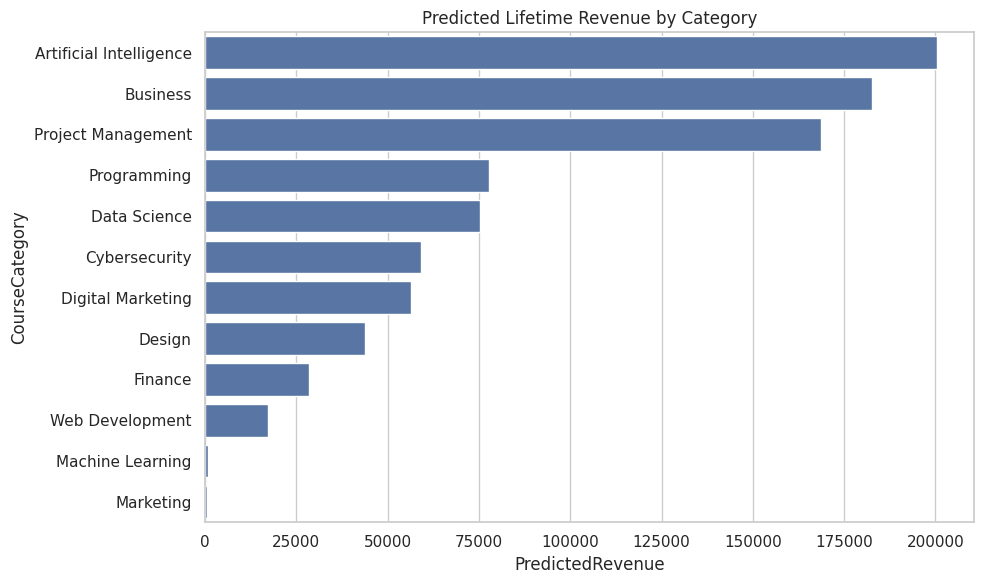

In [30]:
course_perf["PredictedTotalEnrollments"] = np.clip(final_enrollment_model.predict(course_perf[CL_FEATURES]), 0, None)
course_perf["PredictedTotalRevenue"] = np.clip(final_revenue_model.predict(course_perf[CL_FEATURES]), 0, None)

category_forecast = (
    course_perf.groupby("CourseCategory")
    .agg(
        ActualEnrollments=("TotalEnrollments", "sum"),
        PredictedEnrollments=("PredictedTotalEnrollments", "sum"),
        ActualRevenue=("TotalRevenue", "sum"),
        PredictedRevenue=("PredictedTotalRevenue", "sum"),
    )
    .reset_index()
    .sort_values("PredictedRevenue", ascending=False)
)
display(category_forecast)

plt.figure(figsize=(10, 6))
sns.barplot(data=category_forecast, x="PredictedRevenue", y="CourseCategory")
plt.title("Predicted Lifetime Revenue by Category")
plt.tight_layout()
plt.show()

In [31]:
top_courses = course_perf[[
    "CourseID", "CourseName", "CourseCategory", "CoursePrice",
    "TotalEnrollments", "PredictedTotalEnrollments", "TotalRevenue", "PredictedTotalRevenue"
]].copy()

print("TOP 10 COURSES BY PREDICTED LIFETIME ENROLLMENT")
display(top_courses.sort_values("PredictedTotalEnrollments", ascending=False).head(10))

print("\nTOP 10 COURSES BY PREDICTED LIFETIME REVENUE")
display(top_courses.sort_values("PredictedTotalRevenue", ascending=False).head(10))

TOP 10 COURSES BY PREDICTED LIFETIME ENROLLMENT


,CourseID,CourseName,CourseCategory,CoursePrice,TotalEnrollments,PredictedTotalEnrollments,TotalRevenue,PredictedTotalRevenue
20,CR00021,Data Analysis with Python,Data Science,0.00,196,182.738539,0.00,191.100863
21,CR00022,Data Visualization,Data Science,0.00,177,182.233715,0.00,191.100863
22,CR00023,Machine Learning Fundamentals,Data Science,0.00,185,176.880366,0.00,191.100863
24,CR00025,Statistical Analysis,Data Science,299.57,192,175.993750,57517.44,55352.761301
2,CR00003,C++ for Beginners,Programming,0.00,173,174.386067,0.00,136.744225
57,CR00058,Social Media Strategy,Digital Marketing,0.00,194,173.992522,0.00,136.744225
42,CR00043,Corporate Finance,Finance,0.00,182,173.759684,0.00,136.744225
35,CR00036,Agile Project Management,Project Management,0.00,177,173.525610,0.00,136.744225
9,CR00010,3D Modeling,Design,0.00,180,171.401099,0.00,136.744225
47,CR00048,AI Ethics,Artificial Intelligence,0.00,186,170.989505,0.00,136.744225



TOP 10 COURSES BY PREDICTED LIFETIME REVENUE


,CourseID,CourseName,CourseCategory,CoursePrice,TotalEnrollments,PredictedTotalEnrollments,TotalRevenue,PredictedTotalRevenue
49,CR00050,Computer Vision,Artificial Intelligence,490.90,174,169.712152,85416.60,84135.574075
11,CR00012,Business Strategy,Business,487.92,173,165.692709,84410.16,83607.211247
0,CR00001,Python Basics,Programming,472.28,164,169.750984,77453.92,77230.743039
48,CR00049,Deep Learning,Artificial Intelligence,415.51,163,160.305723,67728.13,66984.163193
33,CR00034,Data Encryption,Cybersecurity,394.26,150,153.598968,59139.00,58668.599886
38,CR00039,Project Planning,Project Management,346.71,167,160.438791,57900.57,57733.478073
39,CR00040,Leadership in Projects,Project Management,327.99,174,161.660996,57070.26,56018.919033
24,CR00025,Statistical Analysis,Data Science,299.57,192,175.993750,57517.44,55352.761301
37,CR00038,Risk Management,Project Management,342.61,158,165.954294,54132.38,54518.527743
10,CR00011,Entrepreneurship 101,Business,326.02,151,161.387393,49229.02,51250.285028


## 12. Save Models & Outputs

In [32]:
enrollment_results_df.to_csv(OUTPUT_DIR / "monthly_enrollment_model_comparison.csv", index=False)
enrollment_cl_results.to_csv(OUTPUT_DIR / "course_level_enrollment_model_comparison.csv", index=False)
revenue_cl_results.to_csv(OUTPUT_DIR / "course_level_revenue_model_comparison.csv", index=False)
category_forecast.to_csv(OUTPUT_DIR / "category_forecast.csv", index=False)
top_courses.to_csv(OUTPUT_DIR / "course_predictions.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "feature_importance_enrollment.csv", index=False)
importance_rev_df.to_csv(OUTPUT_DIR / "feature_importance_revenue.csv", index=False)

course_perf[[
    "CourseID", "CourseName", "TotalEnrollments", "EnrollmentLower90", "EnrollmentUpper90",
    "TotalRevenue", "RevenueLower90", "RevenueUpper90"
]].to_csv(OUTPUT_DIR / "prediction_intervals.csv", index=False)

pd.DataFrame([
    {"Target": "TotalEnrollments", "Model": best_enrollment_model_name, "BestParams": str(enrollment_best_params),
     "UntunedCV_R2": enrollment_cl_results.iloc[0]["R2 (mean)"], "TunedCV_R2": enrollment_tuned_r2, "Train_R2": enrollment_train_r2},
    {"Target": "TotalRevenue", "Model": best_revenue_model_name, "BestParams": str(revenue_best_params),
     "UntunedCV_R2": revenue_cl_results.iloc[0]["R2 (mean)"], "TunedCV_R2": revenue_tuned_r2, "Train_R2": revenue_train_r2},
]).to_csv(OUTPUT_DIR / "model_tuning_summary.csv", index=False)

joblib.dump(final_enrollment_model, MODEL_DIR / "final_enrollment_model.pkl")
joblib.dump(final_revenue_model, MODEL_DIR / "final_revenue_model.pkl")

print("Saved outputs to", OUTPUT_DIR.resolve())
print("Saved models to", MODEL_DIR.resolve())

Saved outputs to /home/claude/outputs/predictions
Saved models to /home/claude/models


## 13. Executive Summary (draft)

- **Enrollment count is not predictable from the available features, at any grain checked.**
  Monthly per-course (Section 4, correlation ≈ -0.04), category-month (Section 5, ≈0.02 net of
  price composition), and course lifetime totals (Section 6-8, every model CV R² < 0) all point to
  the same conclusion. This is a genuine, well-evidenced finding about this dataset — not a modeling
  shortfall — and it should be stated plainly in the paper rather than papered over with a
  best-of-six-models number.
- **Revenue IS predictable (R² ≈ 0.96-0.98 course-level; ≈0.88-0.89 category-monthly), but mostly
  because revenue is mechanically price × a roughly constant enrollment count in this dataset**
  (`Amount` equals `CoursePrice` exactly; enrollment varies only ~7% around its mean). Present this
  as a genuinely useful *pricing/revenue-planning* result, not as evidence the model has learned a
  demand-driven relationship.
- **Overfitting check (Section 9):** the enrollment model shows a large train-vs-CV R² gap
  (in-sample R²≈0.37 vs CV R²≈-0.17) — a textbook overfitting signature, confirming there's no real
  signal for it to learn. The revenue model shows almost no gap, consistent with it being the
  reliable one.
- **Hyperparameter tuning (Section 8)** moved the enrollment CV R² only slightly (still negative) —
  evidence this is sample-size- and signal-limited, not tuning-limited; more grid search won't fix
  it. Revenue tuning was likewise a small refinement over an already-strong model.
- **Predictions carry genuine uncertainty at n=60** — Section 10's bootstrap intervals should be
  reported as ranges. Note the caveat there too: bootstrap intervals reflect *training* variability,
  not the enrollment model's poor out-of-sample generalization, so treat enrollment intervals as
  optimistic and revenue intervals as reasonably trustworthy.
- **Recommended framing for the paper and dashboard:** lead with revenue/pricing forecasting as the
  working deliverable; present enrollment-count prediction as a documented, evidence-backed negative
  result with a clear recommendation (collect more history — 24+ months — and/or richer behavioral
  features such as marketing spend or traffic, since price/rating/duration alone don't explain who
  enrolls).
- **Feature importance** (Section 7) — for revenue, expect `CoursePrice`/`PriceBand` to dominate;
  any other feature with real weight (category, teacher rating) is the interesting finding. Don't
  quote the enrollment feature-importance chart as predictive — it describes in-sample correlation
  on a model that doesn't generalize.

*(Streamlit dashboard should lead with the Section 8-11 revenue model, its prediction intervals, and
the category roll-up. The enrollment model can still be shown, but labeled clearly as exploratory /
low-confidence, with the Section 4 naive-baseline comparison surfaced as the "why" — transparency
here builds more credibility with stakeholders than hiding the limitation.)*